In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h 
from _CO_Oxidation import wrapper_acid as wp
from _CO_Oxidation.wrapper_acid import plot_posteriors, plot_model_fits, plot_coverages, plot_drc

C_H_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Pt66Ru33_acid.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_H_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_H_in = wp.C_H_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    rate_model = pt.exp(log_rate)
    sigma_rel = pm.Gamma('sigma_rel', alpha=2, beta=20)
    sigma_base = pm.HalfNormal('sigma_base', sigma=1e-2)
    exponent =  pm.HalfNormal('exponent', sigma=1)
    sigma_model = pt.sqrt(sigma_base**2 + (sigma_rel**2)*(rate_model ** exponent))
    # sigma_total = pt.sqrt(wp.rate_SD_obs**2 + sigma_model**2)
    rate = pm.StudentT('rate', nu=4, mu=rate_model, sigma=sigma_model, observed=wp.rate_obs_matrix)
    return rate

Ru_comp = 0.33

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.49,15
,3000,0,0.38,15
,3000,0,0.43,15
,3000,0,0.46,7


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    66.86    34.59
p_loo        9.51        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      709  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



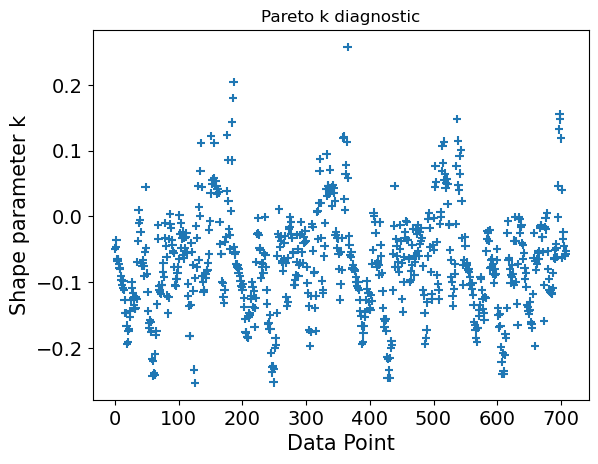

In [2]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.065  0.004  -0.073   -0.058      0.000      0.0    1708.0    1952.0    1.0
deltaG4_0   0.912  0.006   0.901    0.923      0.000      0.0    1503.0    1701.0    1.0
Gact2_0     0.682  0.002   0.678    0.685      0.000      0.0    1771.0    2257.0    1.0
sigma_rel   0.466  0.028   0.412    0.517      0.001      0.0    2042.0    2466.0    1.0
sigma_base  0.006  0.004   0.000    0.014      0.000      0.0    2155.0    1211.0    1.0
exponent    0.353  0.018   0.322    0.388      0.000      0.0    1544.0    1983.0    1.0


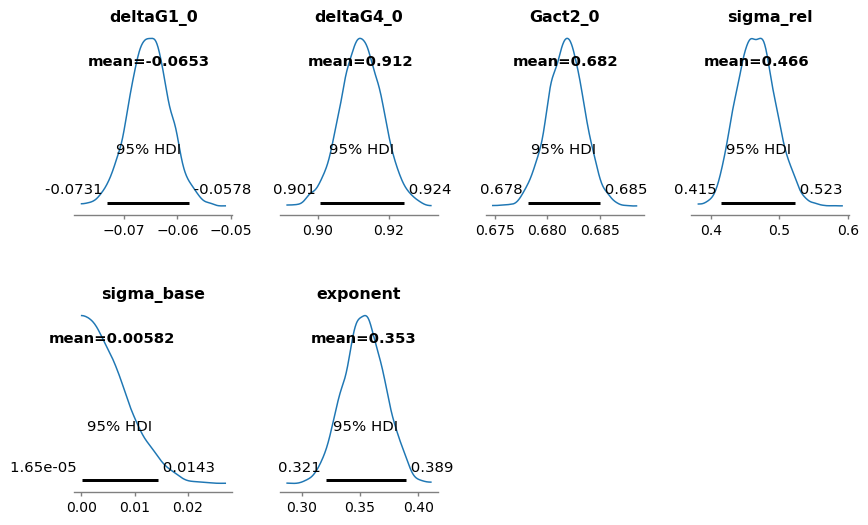

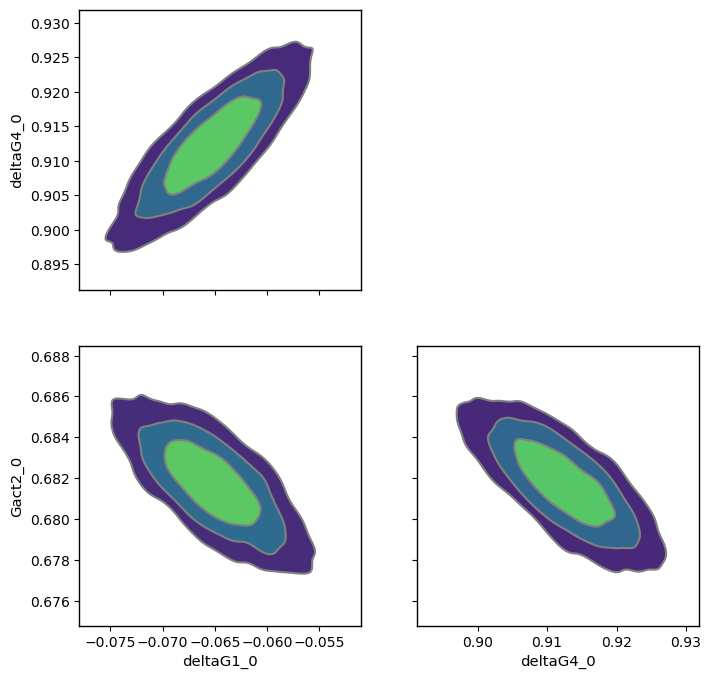

Sampling: [rate]


rate: 0.538


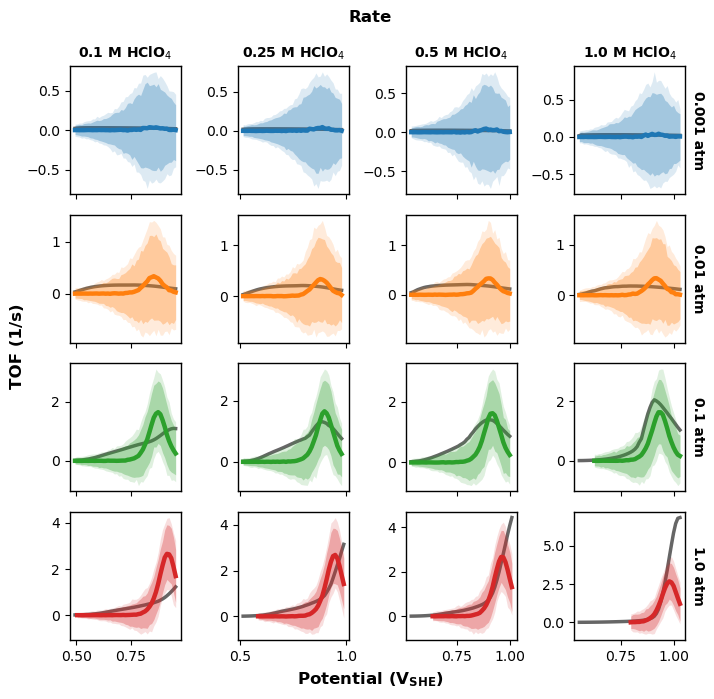

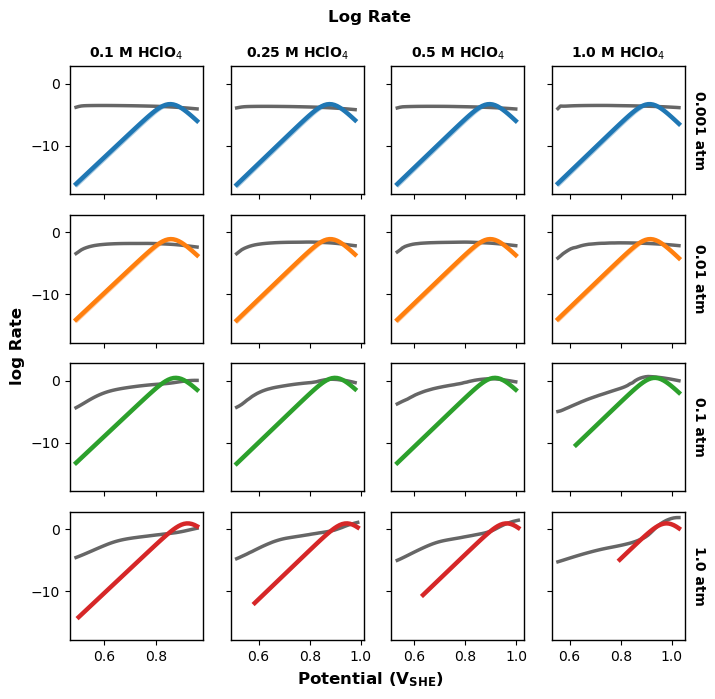

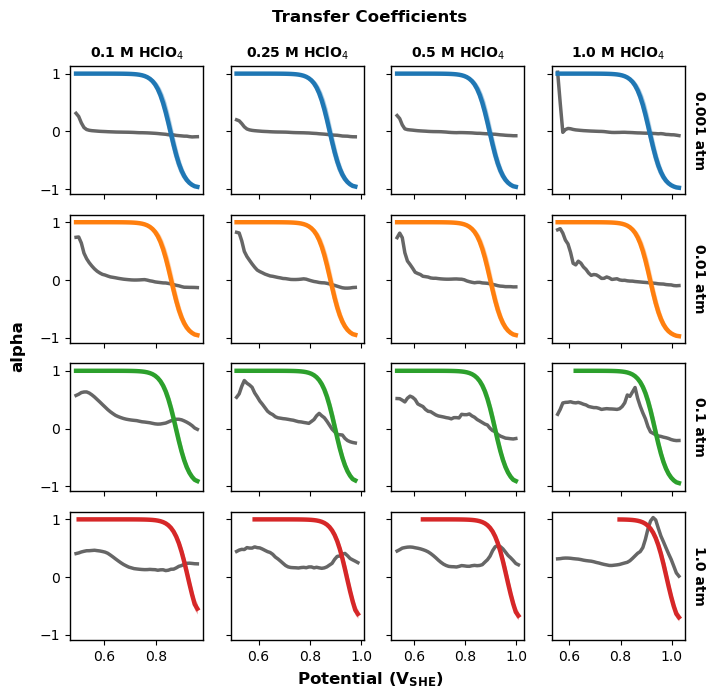

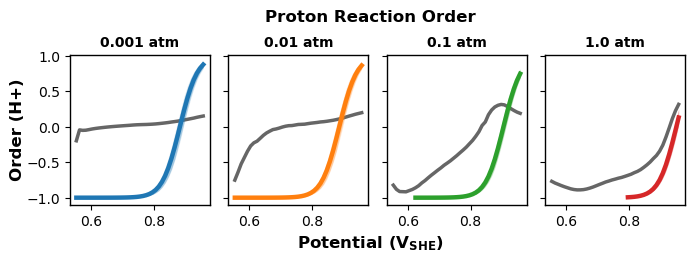

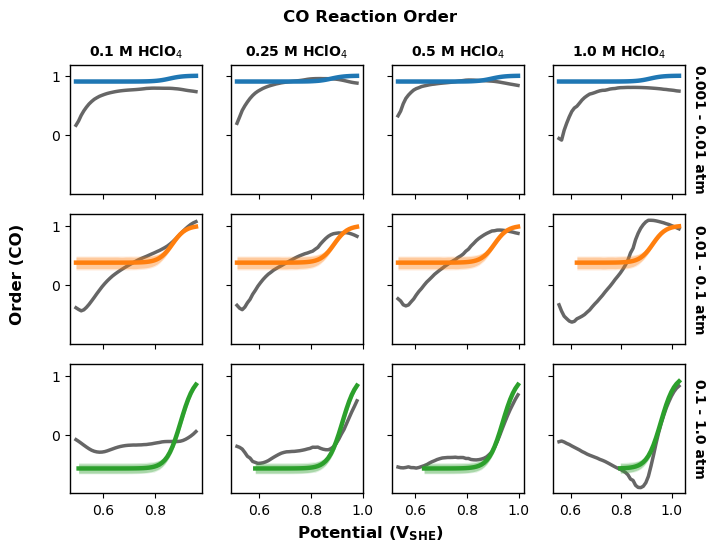

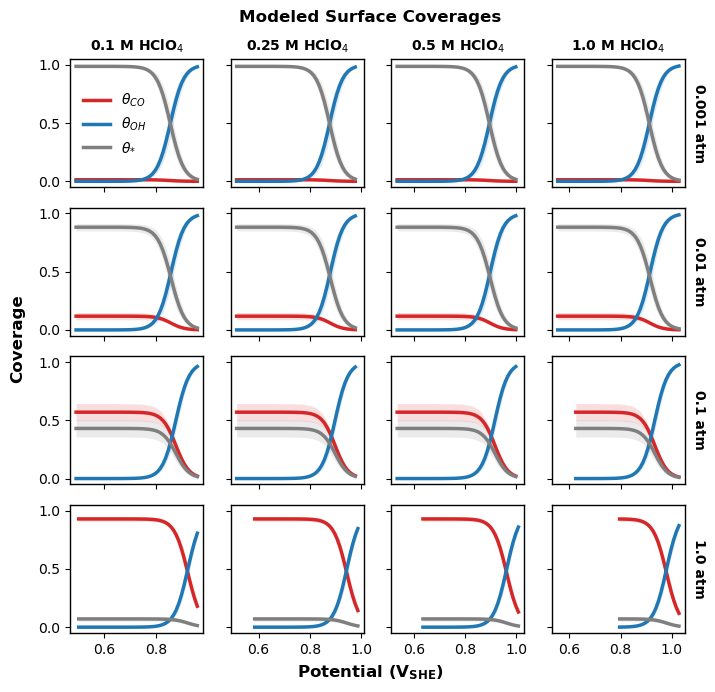

In [3]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)

# ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,15
,3000,0,0.23,63
,3000,0,0.22,31
,3000,0,0.22,47


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   772.22    64.65
p_loo       11.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      709  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



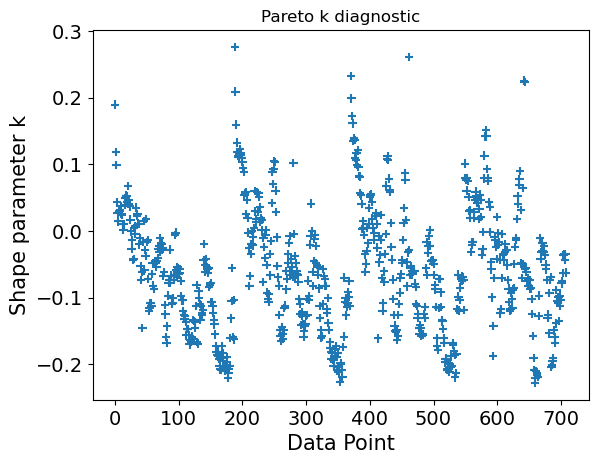

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + H2O -> COOH* + H+ + (e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)  
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.099  0.001  -0.102   -0.097      0.000    0.000    1143.0    1456.0   1.00
deltaG4_0   1.010  0.004   1.003    1.016      0.000    0.000    1058.0    1687.0   1.00
Gact2_0     0.770  0.004   0.763    0.777      0.000    0.000     671.0     771.0   1.01
beta_2      0.013  0.004   0.006    0.020      0.000    0.000     679.0     890.0   1.01
sigma_rel   2.025  0.223   1.628    2.458      0.006    0.004    1551.0    1873.0   1.00
sigma_base  0.003  0.000   0.003    0.004      0.000    0.000    1083.0    1372.0   1.00
exponent    4.481  0.158   4.195    4.776      0.004    0.003    1958.0    1850.0   1.00


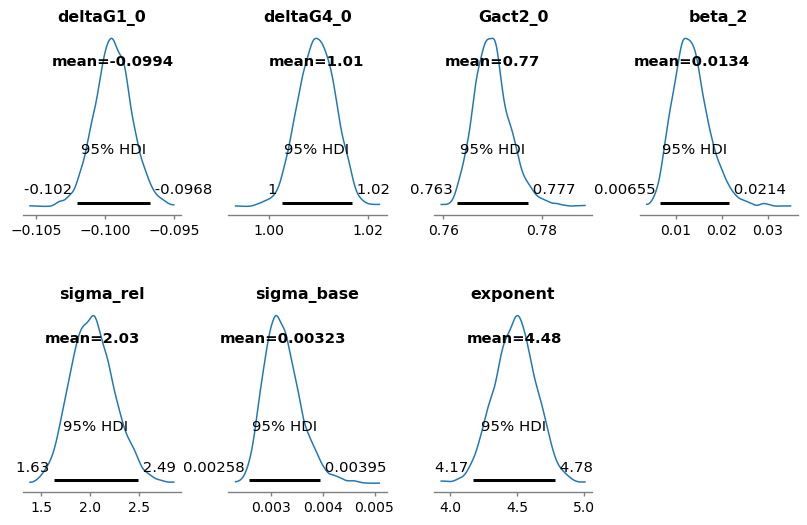

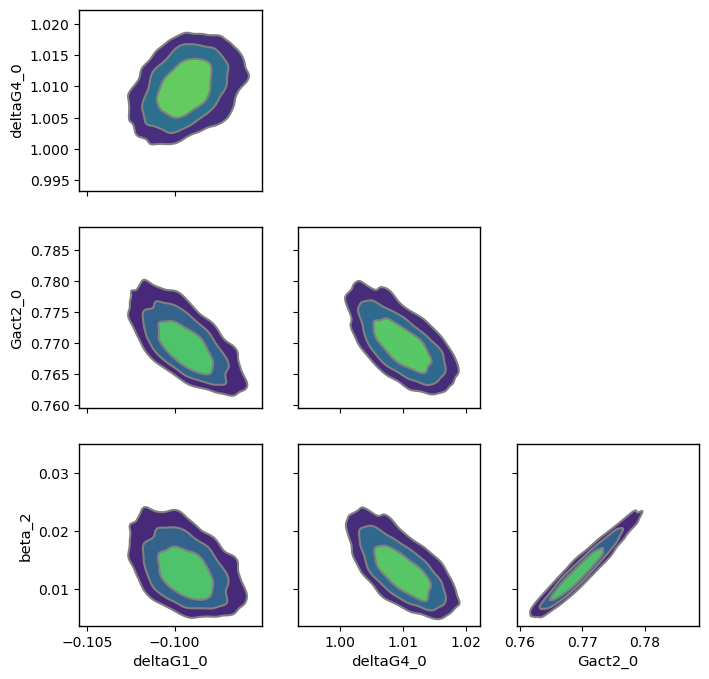

Sampling: [rate]


rate: 0.241


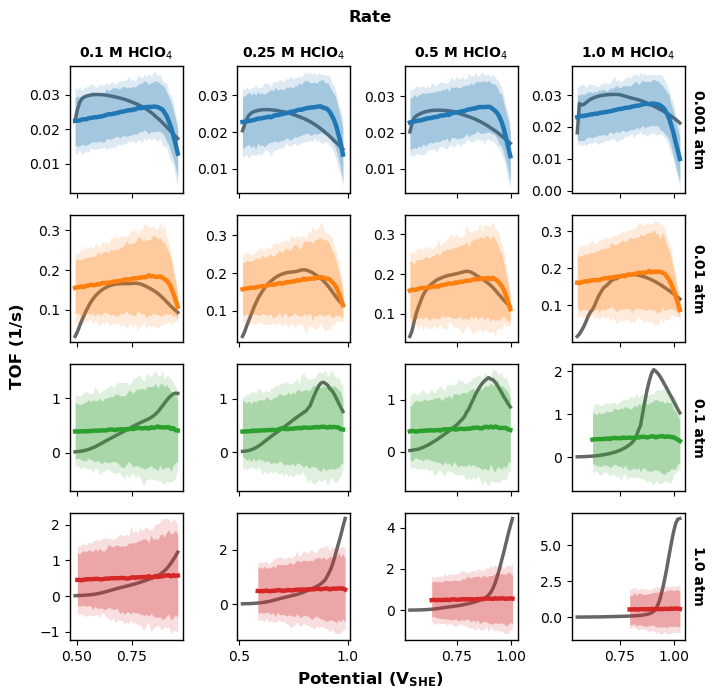

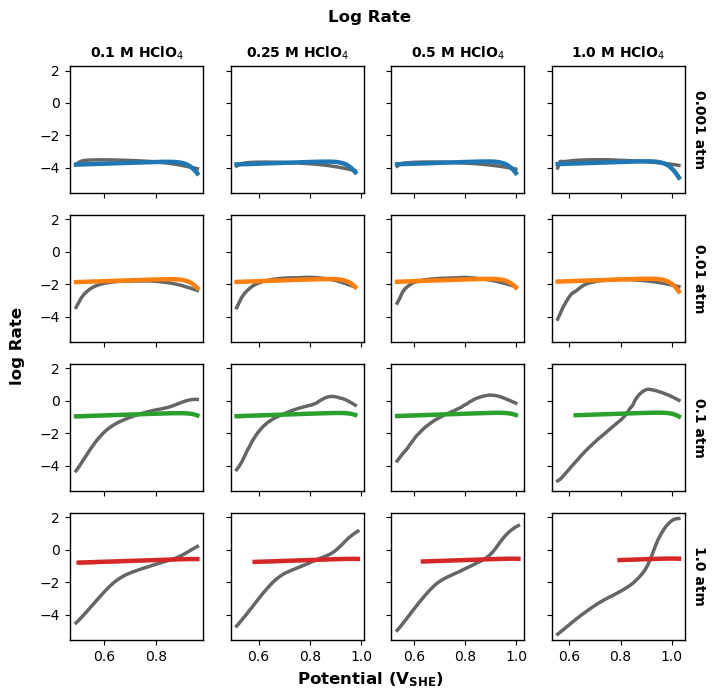

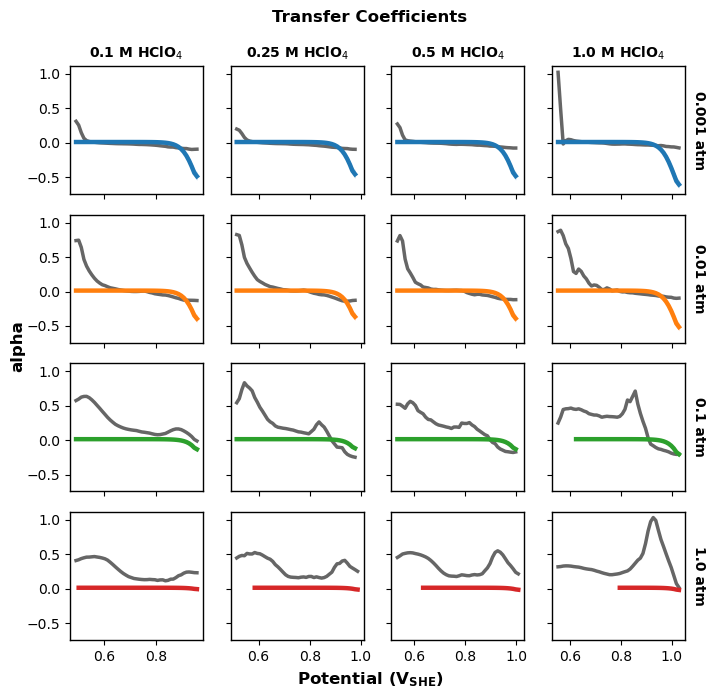

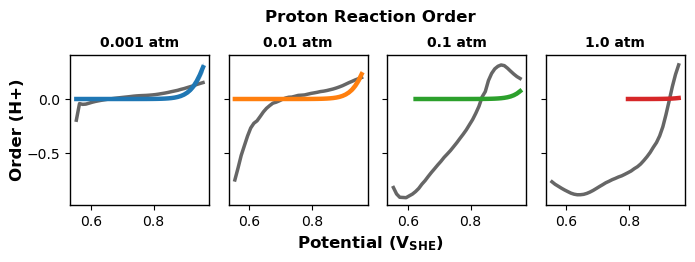

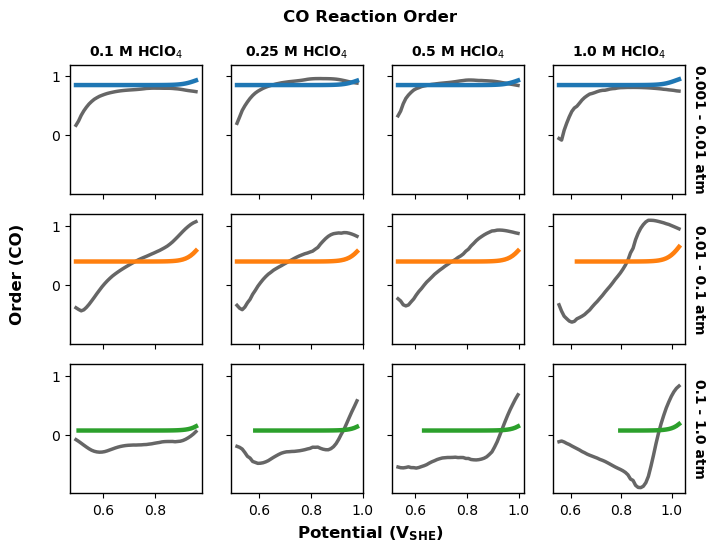

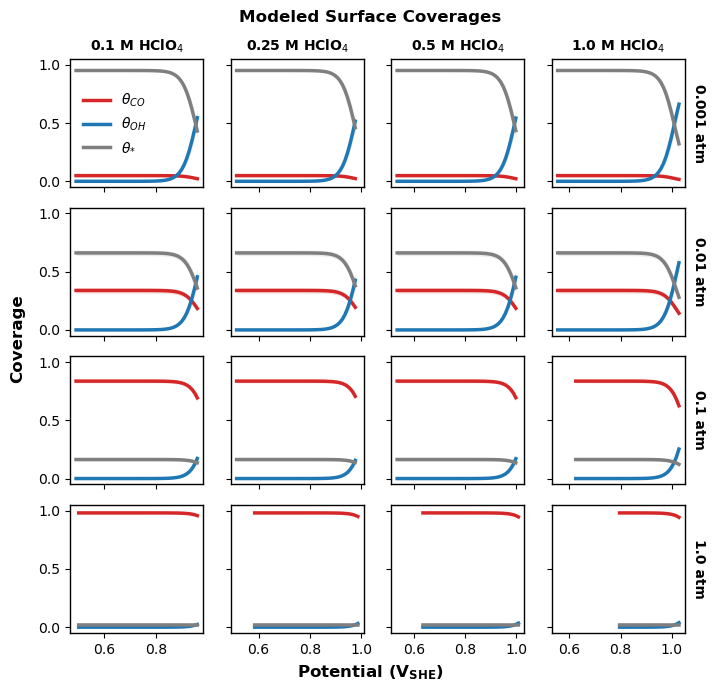

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)

# BF 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,173,0.27,3
,3000,6,0.12,191
,3000,36,0.31,15
,3000,195,0.14,3


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    48.76    43.21
p_loo      721.51        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      665   93.8%
   (0.70, 1]   (bad)         5    0.7%
   (1, Inf)   (very bad)   39    5.5%



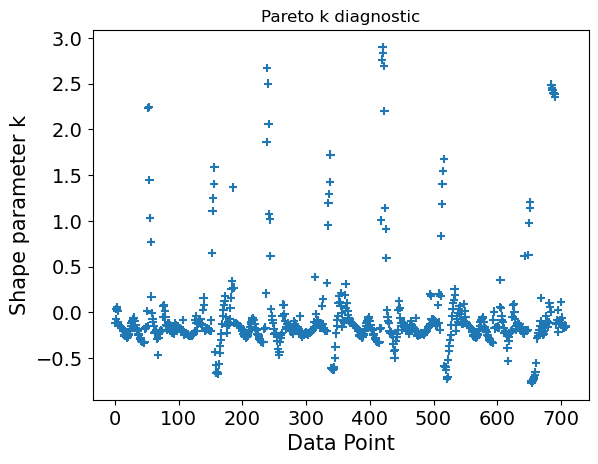

In [6]:
with pm.Model() as BF_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    5. H2O + # <-> OH# + H+ + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pt = log_K4 - np.log(C_H_in)
    term_OH_Ru = log_K5 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pt = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pt]), axis=0)
    log_theta_Ru = - pt.logsumexp(pt.stack([zeros, term_OH_Ru]), axis=0)
    log_theta_CO = term_CO + log_theta_Pt
    log_theta_OH_Pt = term_OH_Pt + log_theta_Pt
    log_theta_OH_Ru = term_OH_Ru + log_theta_Ru

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pt))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ru))
    theta_empty_Pt = pm.Deterministic('theta_empty_Pt', pt.exp(log_theta_Pt))
    theta_empty_Ru = pm.Deterministic('theta_empty_Ru', pt.exp(log_theta_Ru))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ru + np.log(Ru_comp)
    rate = observables(log_rate) 

trace_BF_2, loo_BF_2 = fit_and_evaluate(BF_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.329  0.305  -0.834   -0.080      0.142    0.035       6.0      13.0   1.88
deltaG4_0   0.761  0.360   0.176    1.134      0.169    0.043       6.0      28.0   1.88
deltaG5_0   0.462  0.441  -0.235    0.944      0.202    0.027       6.0     109.0   1.88
Gact2_0     0.714  0.017   0.688    0.732      0.008    0.002       6.0      94.0   1.87
sigma_rel   1.146  0.729   0.360    2.126      0.355    0.011       5.0      14.0   2.00
sigma_base  0.006  0.006   0.000    0.018      0.002    0.002      10.0      21.0   1.78
exponent    2.529  1.929   0.303    4.633      0.955    0.137       6.0      92.0   1.89


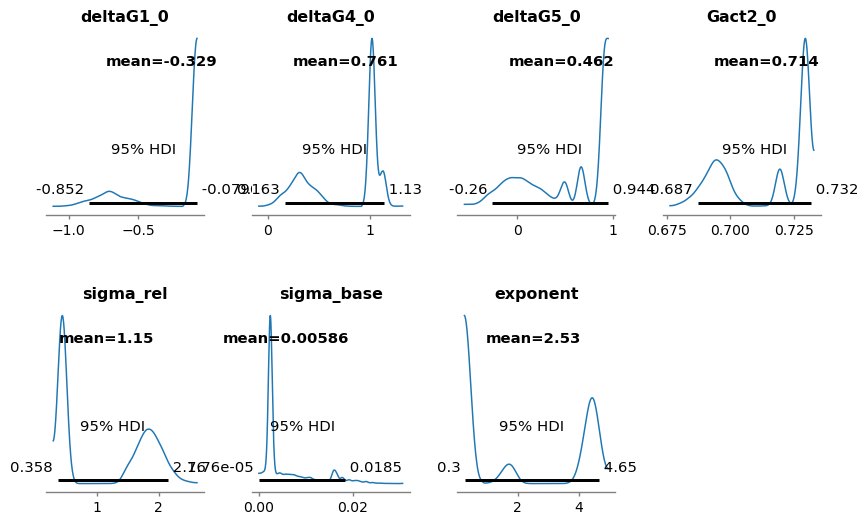

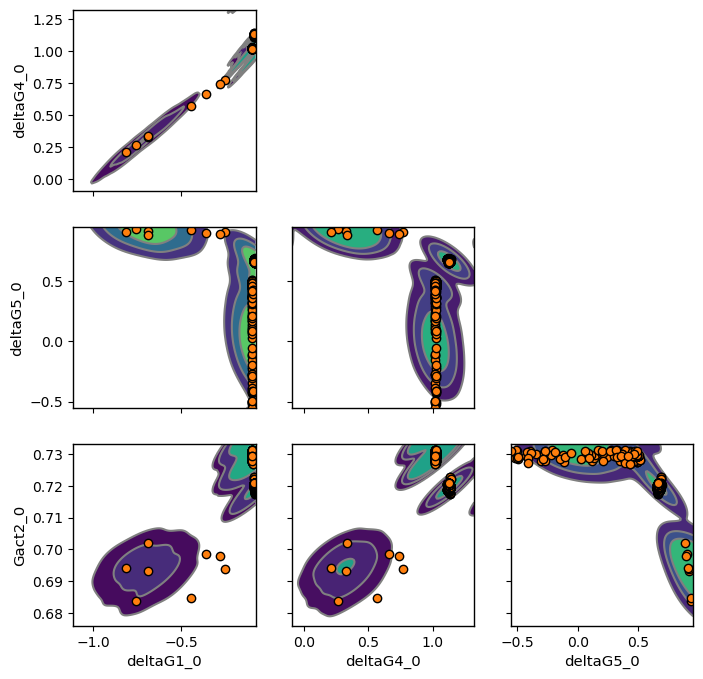

Sampling: [rate]


rate: 0.333


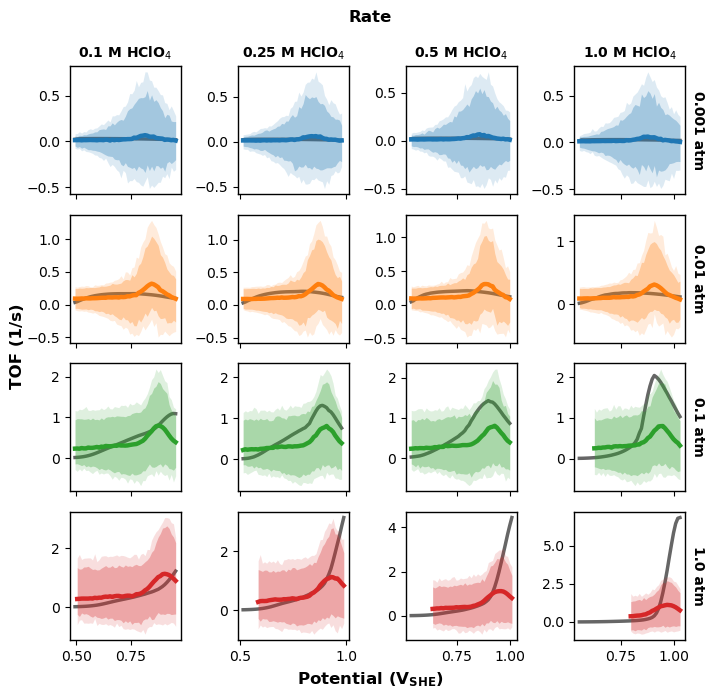

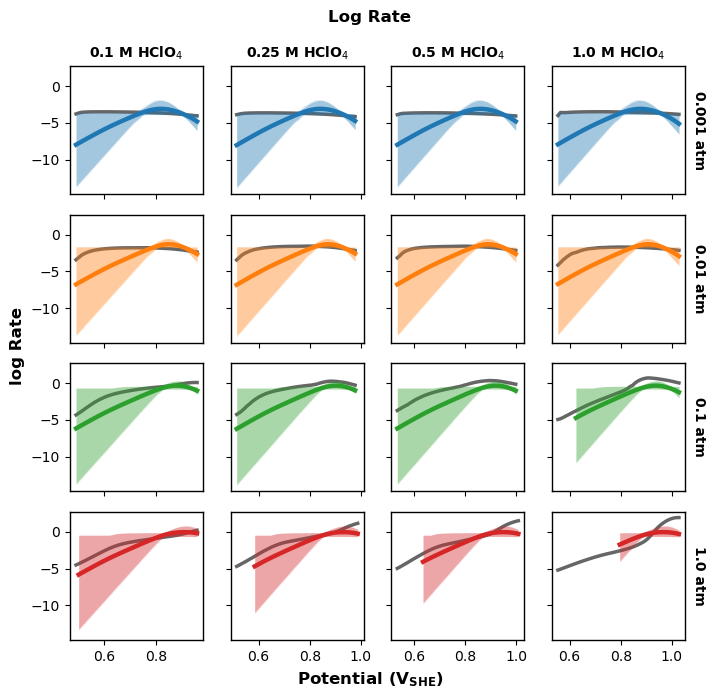

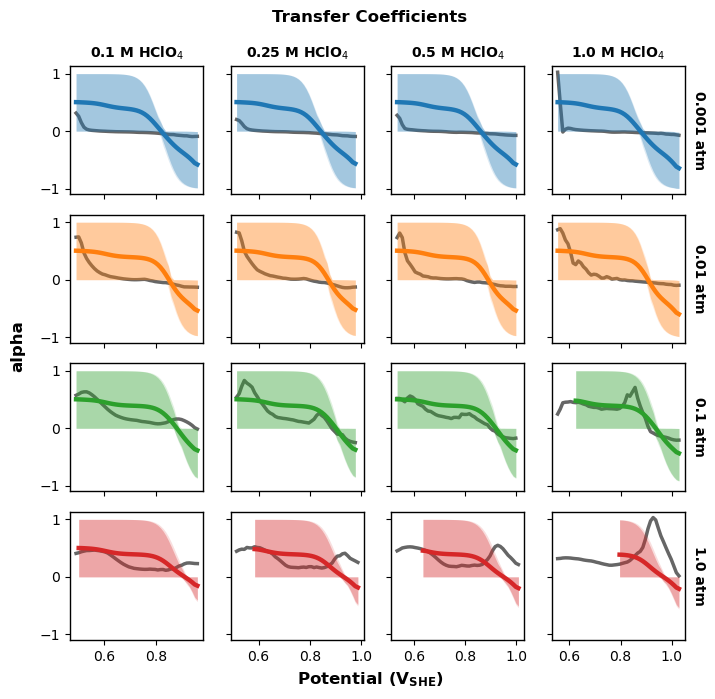

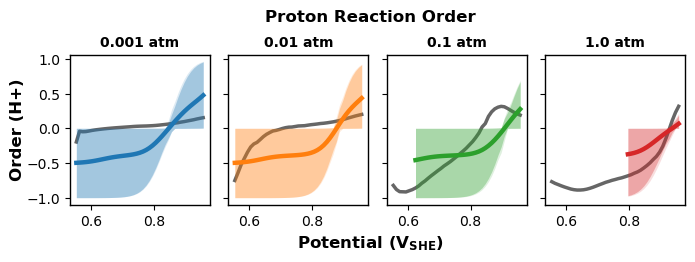

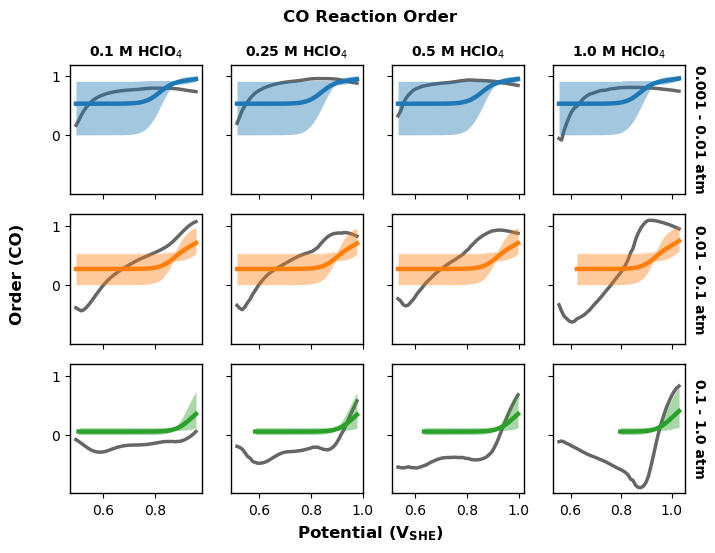

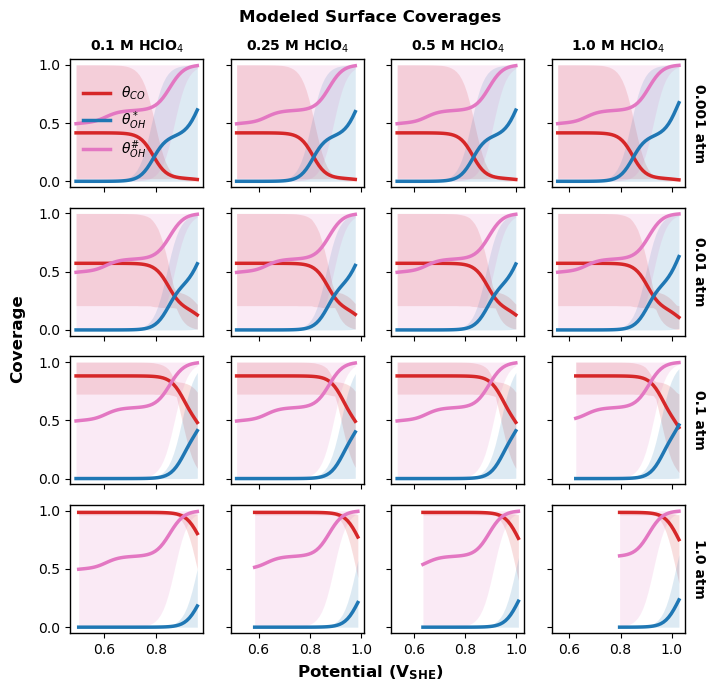

In [7]:
ppc_BF_2 = plot_posteriors(trace_BF_2, BF_2)
plot_model_fits(trace_BF_2, ppc_BF_2); plot_coverages(trace_BF_2)

# LH PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,15
,3000,0,0.20,63
,3000,0,0.23,47
,3000,0,0.21,95


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   861.51    44.71
p_loo       10.71        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      709  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



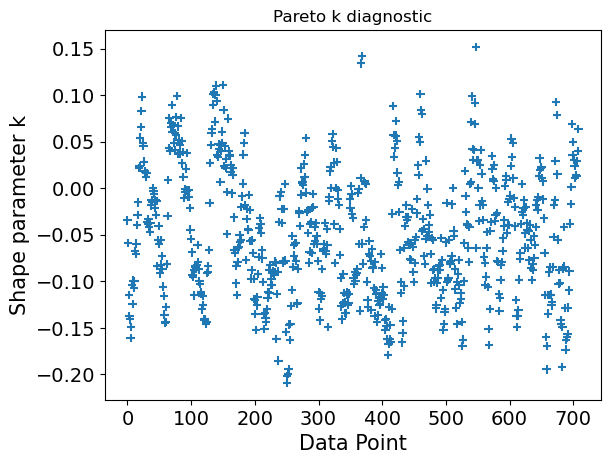

In [8]:
with pm.Model() as LH_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH(q-1)* + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.4, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_PCT, loo_LH_PCT = fit_and_evaluate(LH_PCT)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.093  0.002  -0.096   -0.090      0.000    0.000    1548.0    1877.0    1.0
deltaG4_0   0.207  0.006   0.197    0.217      0.000    0.000    1178.0    1348.0    1.0
Gact2_0     0.788  0.005   0.778    0.797      0.000    0.000    1018.0    1242.0    1.0
beta_2      0.139  0.008   0.123    0.154      0.000    0.000    1029.0    1314.0    1.0
q           0.269  0.007   0.256    0.281      0.000    0.000    1251.0    1296.0    1.0
sigma_rel   0.348  0.022   0.306    0.389      0.000    0.000    3797.0    3021.0    1.0
sigma_base  0.010  0.001   0.008    0.012      0.000    0.000    4192.0    2360.0    1.0
exponent    2.045  0.078   1.904    2.193      0.001    0.001    3497.0    2901.0    1.0


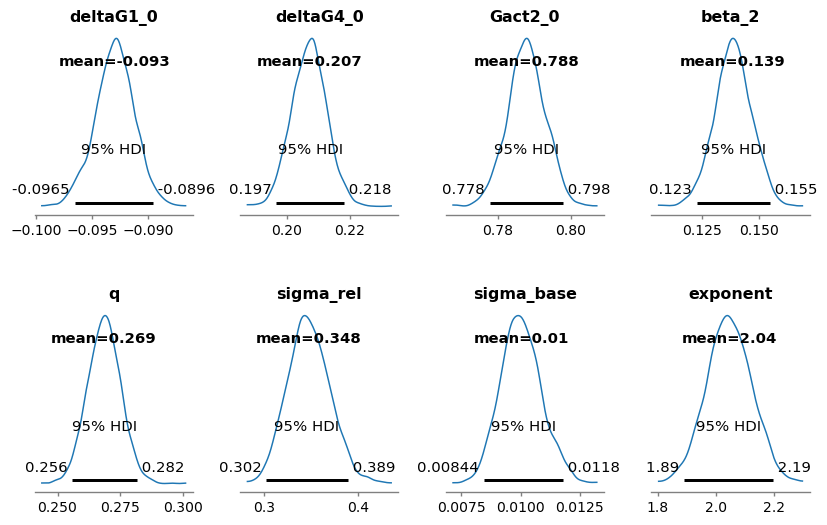

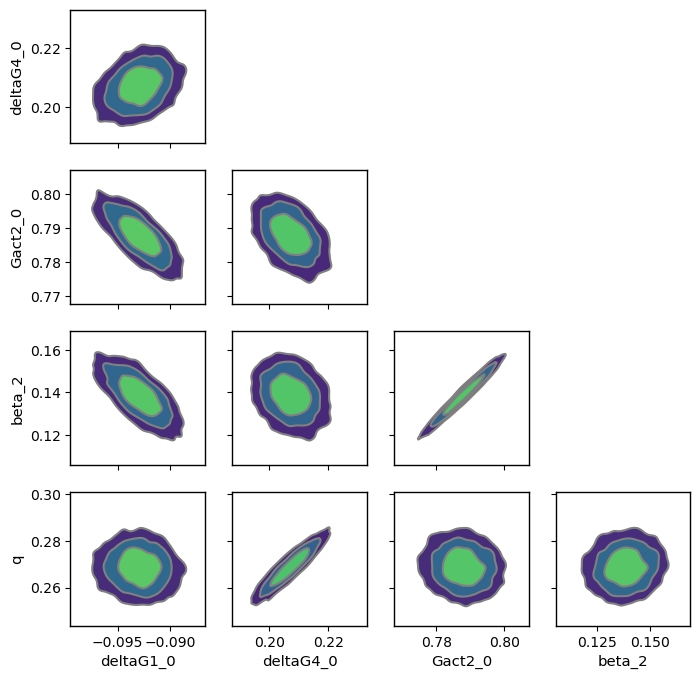

Sampling: [rate]


rate: 0.498


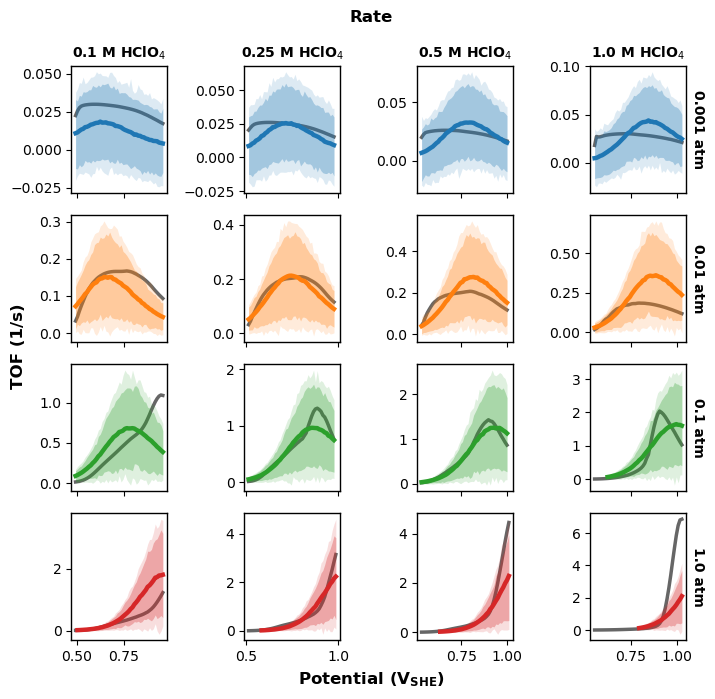

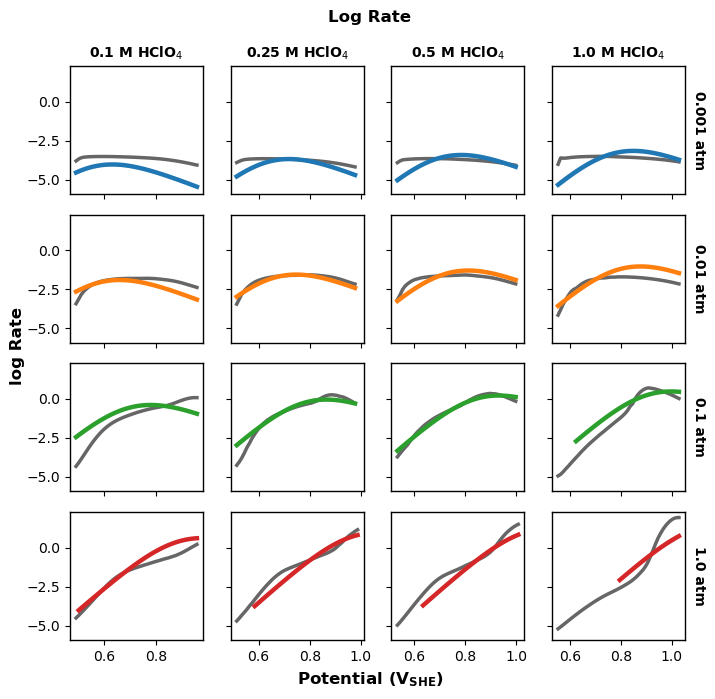

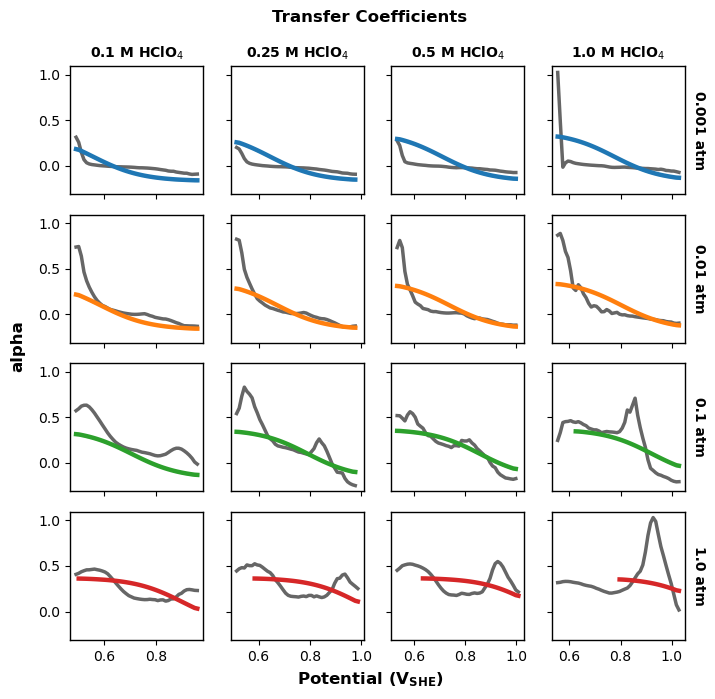

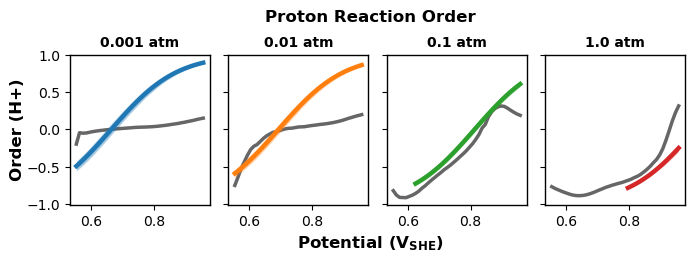

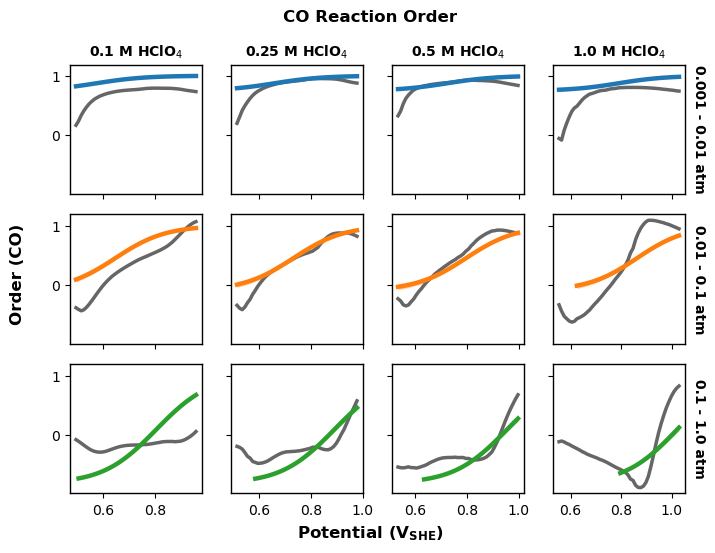

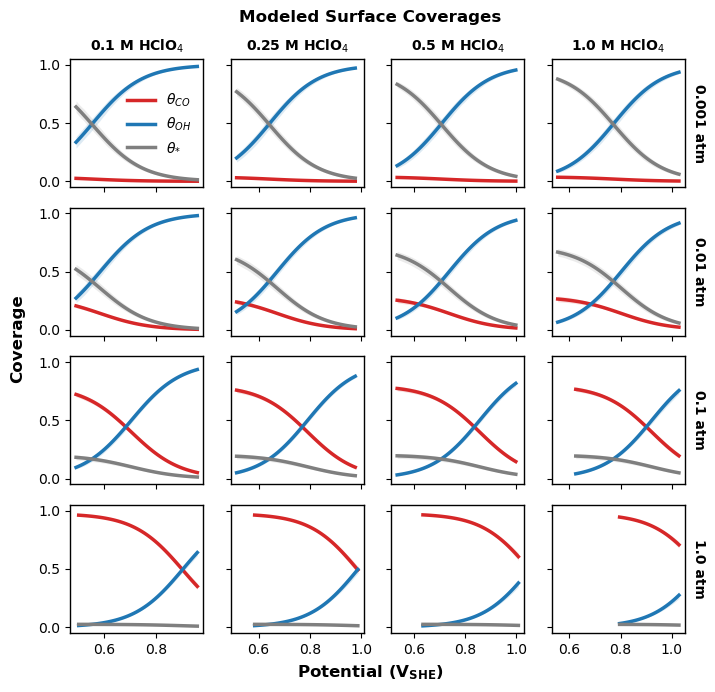

In [9]:
ppc_LH_PCT = plot_posteriors(trace_LH_PCT, LH_PCT)
plot_model_fits(trace_LH_PCT, ppc_LH_PCT); plot_coverages(trace_LH_PCT)

# BF PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.04,127
,3000,4,0.15,31
,3000,0,0.05,255
,3000,0,0.05,63


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   238.60    71.26
p_loo      455.45        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      708   99.9%
   (0.70, 1]   (bad)         1    0.1%
   (1, Inf)   (very bad)    0    0.0%



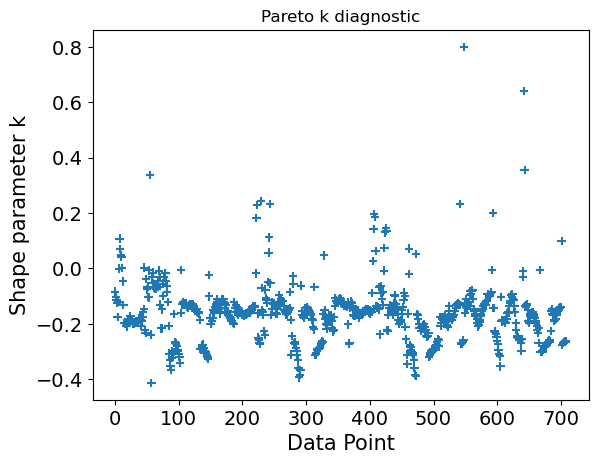

In [10]:
with pm.Model() as BF_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    5. H2O + # <-> OH(q-1)# + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE
    q = pm.Beta('q', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q*E_in
    Gact2 = Gact2_0 - beta_2*(1-q)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pt = log_K4 - np.log(C_H_in)
    term_OH_Ru = log_K5 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pt = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pt]), axis=0)
    log_theta_Ru = - pt.logsumexp(pt.stack([zeros, term_OH_Ru]), axis=0)
    log_theta_CO = term_CO + log_theta_Pt
    log_theta_OH_Pt = term_OH_Pt + log_theta_Pt
    log_theta_OH_Ru = term_OH_Ru + log_theta_Ru

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pt))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ru))
    theta_empty_Pt = pm.Deterministic('theta_empty_Pt', pt.exp(log_theta_Pt))
    theta_empty_Ru = pm.Deterministic('theta_empty_Ru', pt.exp(log_theta_Ru))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ru + np.log(Ru_comp)
    rate = observables(log_rate) 

trace_BF_PCT, loo_BF_PCT = fit_and_evaluate(BF_PCT)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.467  0.241  -0.778   -0.095      0.107    0.047       7.0      32.0   1.54
deltaG4_0   0.381  0.382  -0.018    1.023      0.182    0.096       7.0      31.0   1.54
deltaG5_0   0.074  0.109  -0.208    0.268      0.018    0.042     447.0      29.0   1.42
Gact2_0     1.125  0.224   0.734    1.272      0.112    0.064       7.0      31.0   1.53
beta_2      0.814  0.225   0.329    0.950      0.106    0.068       7.0      35.0   1.53
q           0.260  0.414   0.000    0.987      0.206    0.119       7.0      39.0   1.53
sigma_rel   0.814  0.683   0.374    2.129      0.336    0.199       7.0      29.0   1.53
sigma_base  0.008  0.003   0.003    0.011      0.002    0.001       7.0      29.0   1.53
exponent    3.127  0.782   2.538    4.577      0.387    0.225       7.0      30.0   1.53


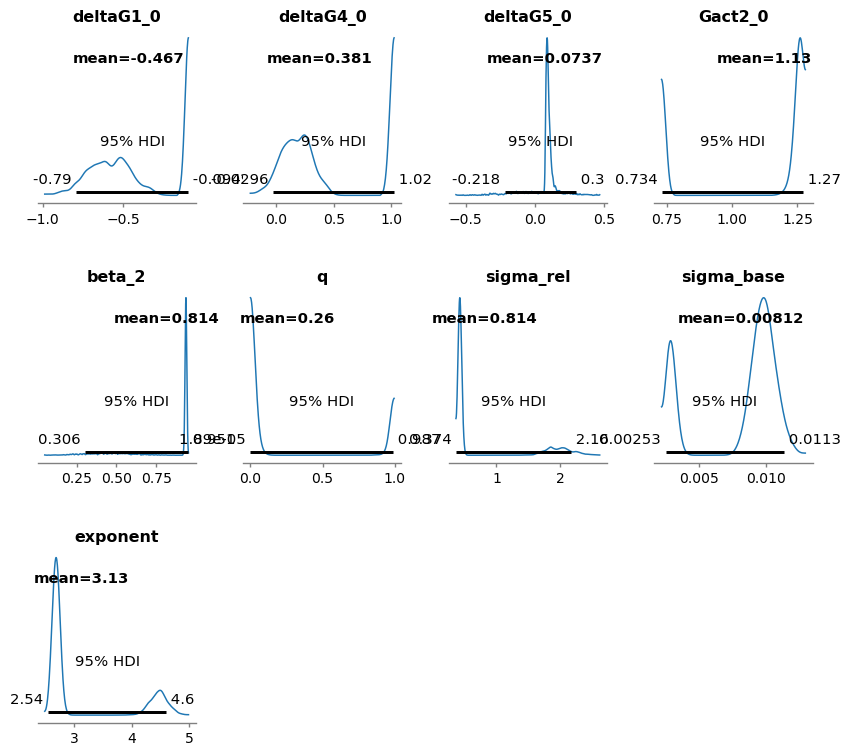

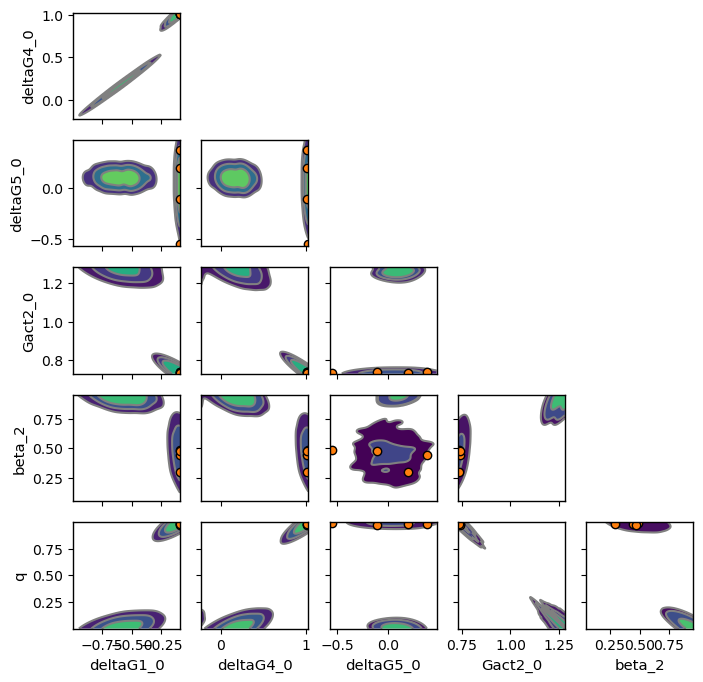

Sampling: [rate]


rate: 0.442


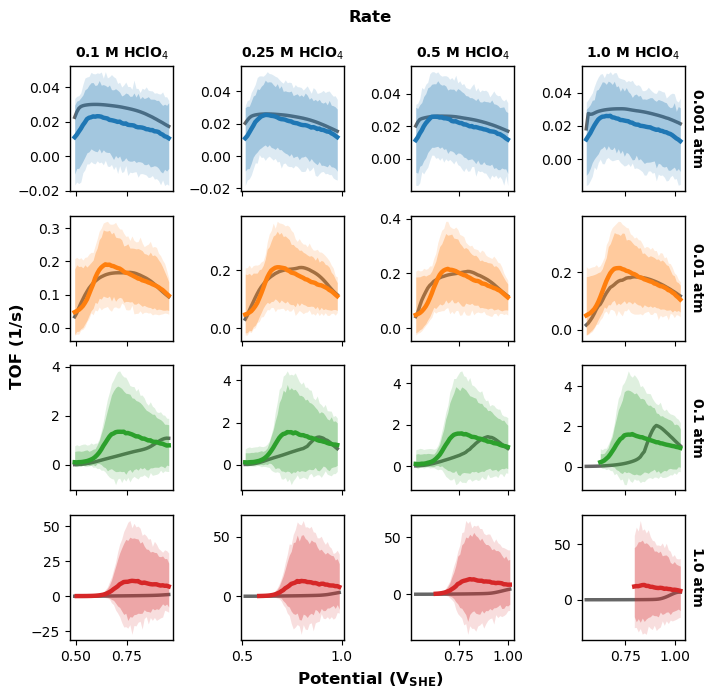

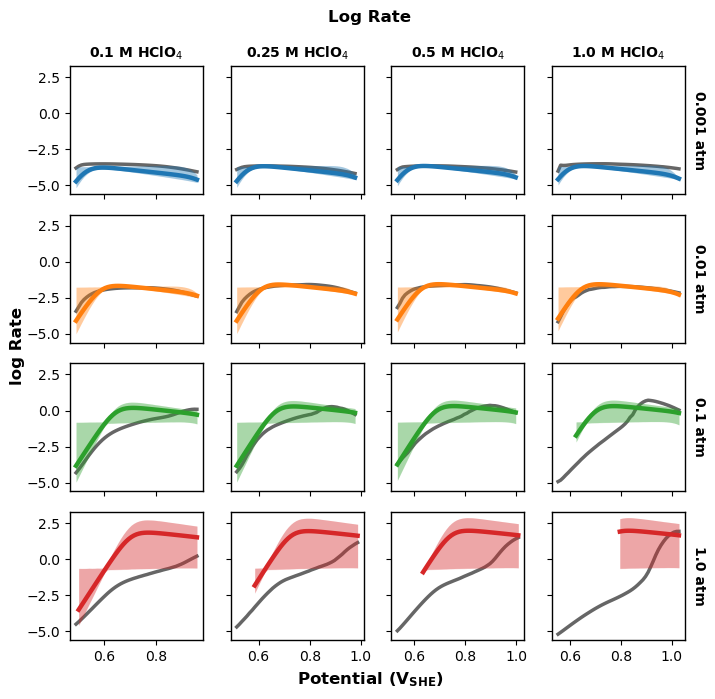

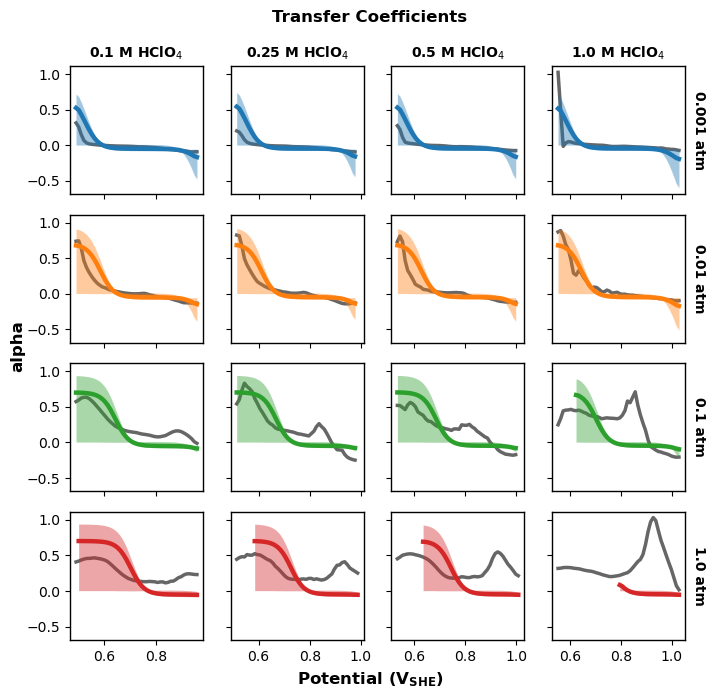

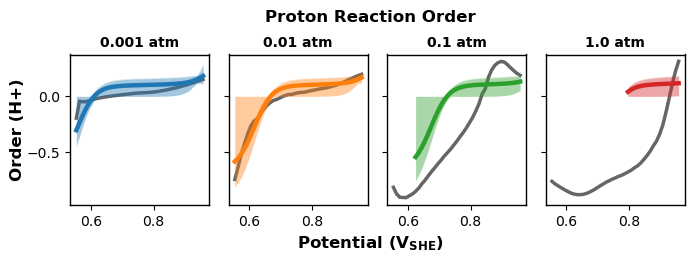

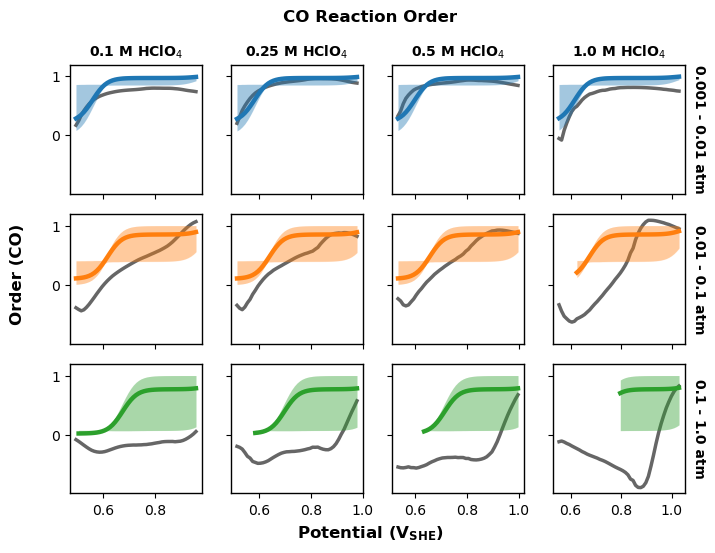

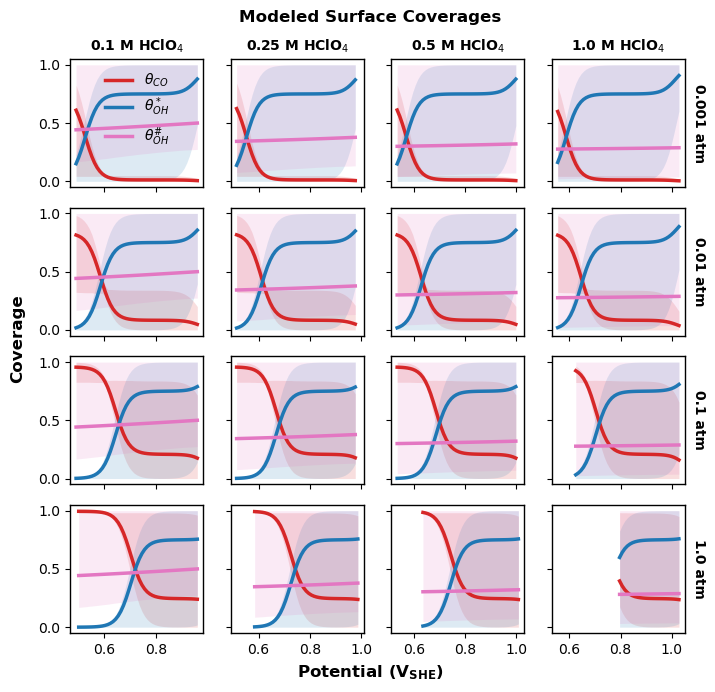

In [11]:
ppc_BF_PCT = plot_posteriors(trace_BF_PCT, BF_PCT)
plot_model_fits(trace_BF_PCT, ppc_BF_PCT); plot_coverages(trace_BF_PCT)

# LH BF PCT

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.11,63
,3000,0,0.16,63
,3000,0,0.14,127
,3000,0,0.13,63


Computed from 4000 posterior samples and 709 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   944.47    47.33
p_loo       77.52        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      709  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



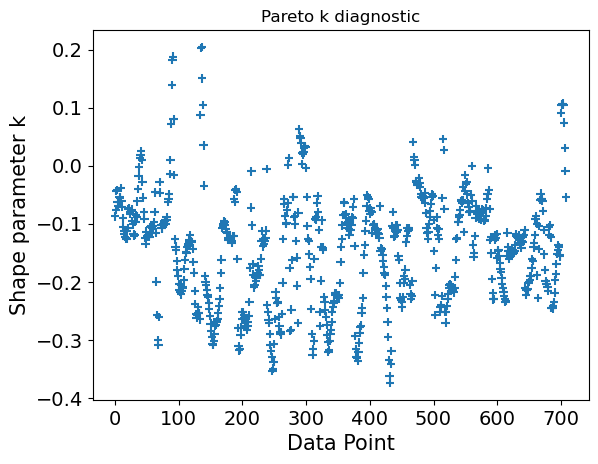

In [13]:
with pm.Model() as LH_BF_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS)
    2b. CO* + OH(q-1)* -> COOH* + * + (1-q)(e-) (RDS)
    3. COOH* -> CO2 + H+ + * + (e-) (Fast)
    4. H2O + * <-> OH* + H+ + (e-) (QEA)
    5. H2O + # <-> OH(q-1)# + H+ + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)   
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2) # at 0V_SHE
    q_BF = pm.Beta('q_BF', alpha=1, beta=1)
    q_LH = pm.Beta('q_LH', alpha=1, beta=1)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q_LH*E_in
    deltaG5 = deltaG5_0 - q_BF*E_in
    Gact2_LH = Gact2_LH_0 - beta_2_LH*(1-q_LH)*E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF*(1-q_BF)*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pt = log_K4 - np.log(C_H_in)
    term_OH_Ru = log_K5 - np.log(C_H_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pt = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pt]), axis=0)
    log_theta_Ru = - pt.logsumexp(pt.stack([zeros, term_OH_Ru]), axis=0)
    log_theta_CO = term_CO + log_theta_Pt
    log_theta_OH_Pt = term_OH_Pt + log_theta_Pt
    log_theta_OH_Ru = term_OH_Ru + log_theta_Ru

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pt))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ru))
    theta_empty_Pt = pm.Deterministic('theta_empty_Pt', pt.exp(log_theta_Pt))
    theta_empty_Ru = pm.Deterministic('theta_empty_Ru', pt.exp(log_theta_Ru))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ru + np.log(Ru_comp)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pt + np.log(1.0 - Ru_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_LH_BF_PCT, loo_LH_BF_PCT = fit_and_evaluate(LH_BF_PCT)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.130  0.029  -0.184   -0.108      0.014    0.008       7.0      34.0   1.53
deltaG4_0   0.211  0.009   0.196    0.230      0.002    0.002      27.0      35.0   1.12
deltaG5_0   0.059  0.015   0.031    0.083      0.006    0.002       7.0      32.0   1.52
Gact2_BF_0  0.947  0.033   0.885    0.978      0.016    0.009       7.0      32.0   1.53
Gact2_LH_0  0.843  0.177   0.728    1.201      0.085    0.053       7.0      32.0   1.53
beta_2_BF   0.314  0.044   0.230    0.356      0.022    0.012       7.0      32.0   1.53
beta_2_LH   0.123  0.153   0.018    0.456      0.070    0.048       7.0      30.0   1.53
q_BF        0.005  0.005   0.000    0.014      0.000    0.000    1969.0    1796.0   1.01
q_LH        0.297  0.029   0.268    0.355      0.014    0.008       7.0      33.0   1.53
sigma_rel   0.439  0.041   0.372    0.519      0.015    0.007       8.0      35.0   1.41
sigma_base  0.005  0.

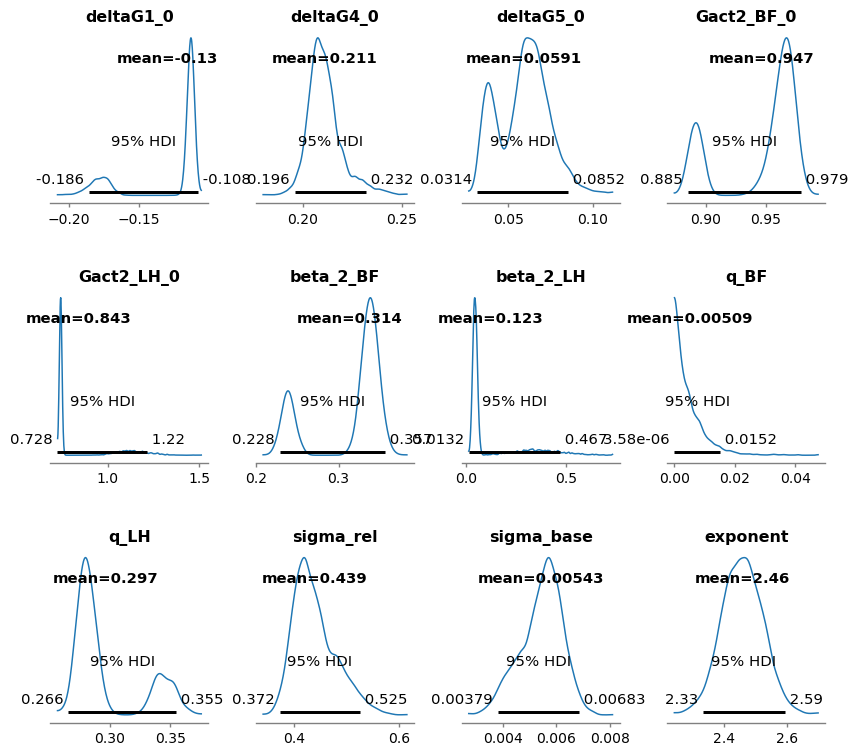

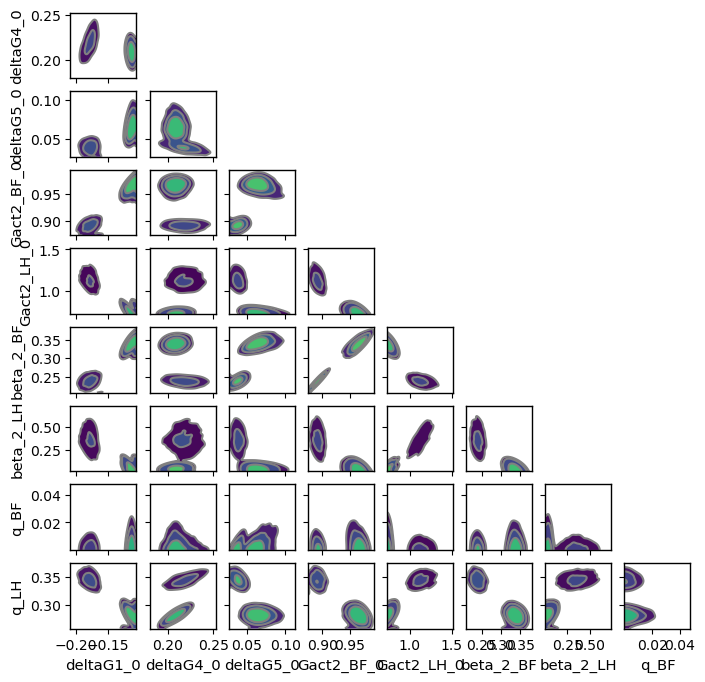

Sampling: [rate]


rate: 0.577


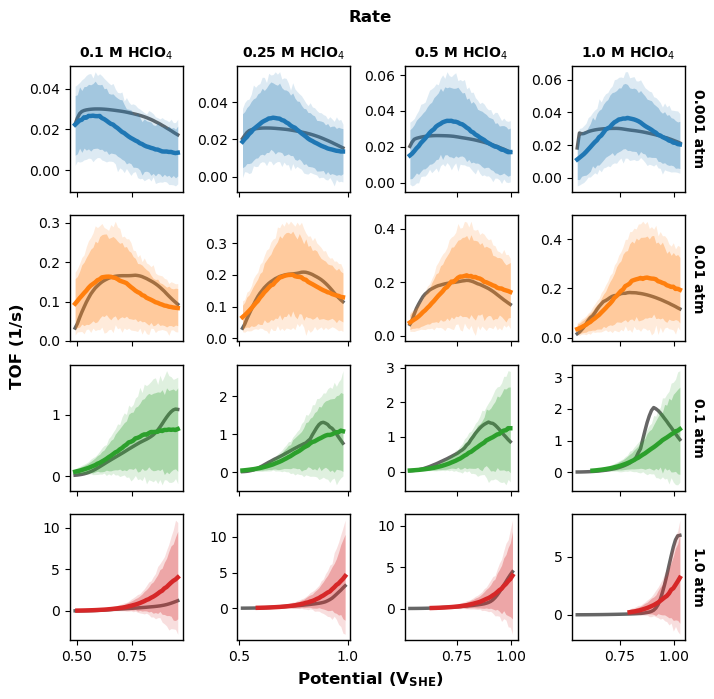

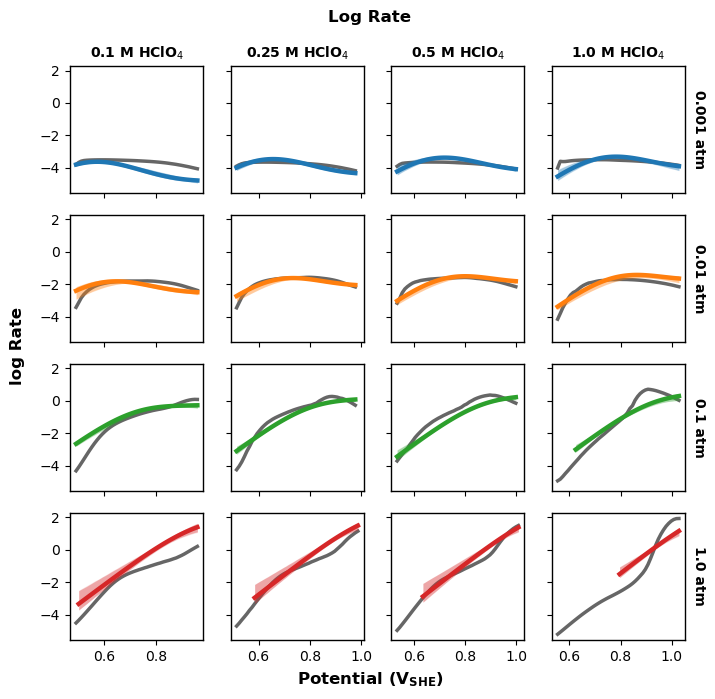

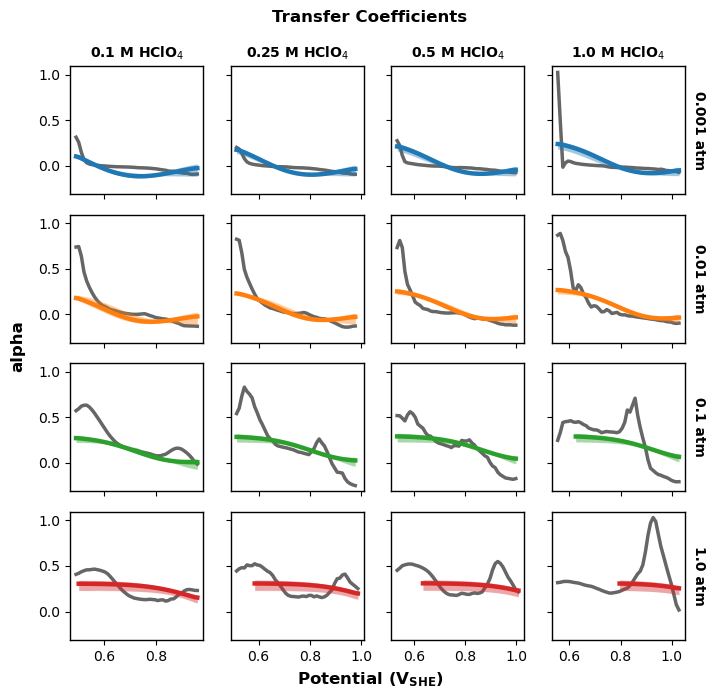

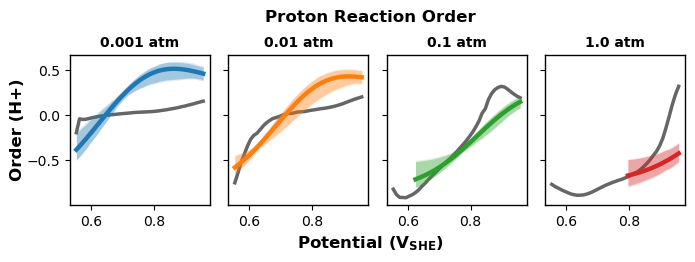

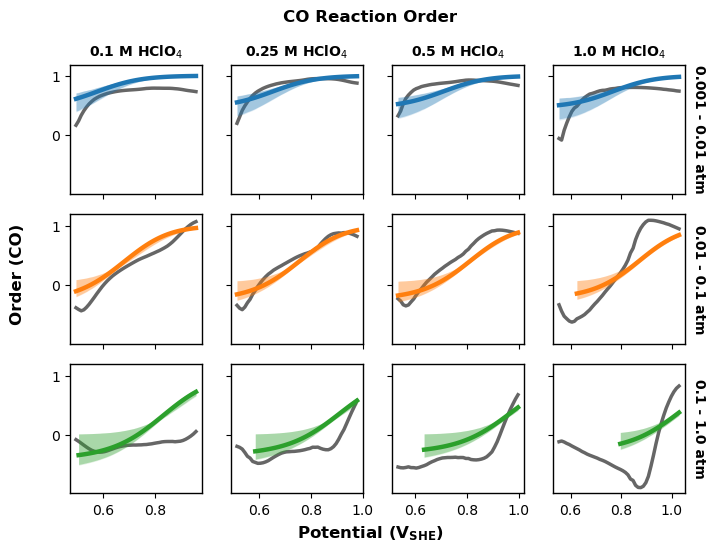

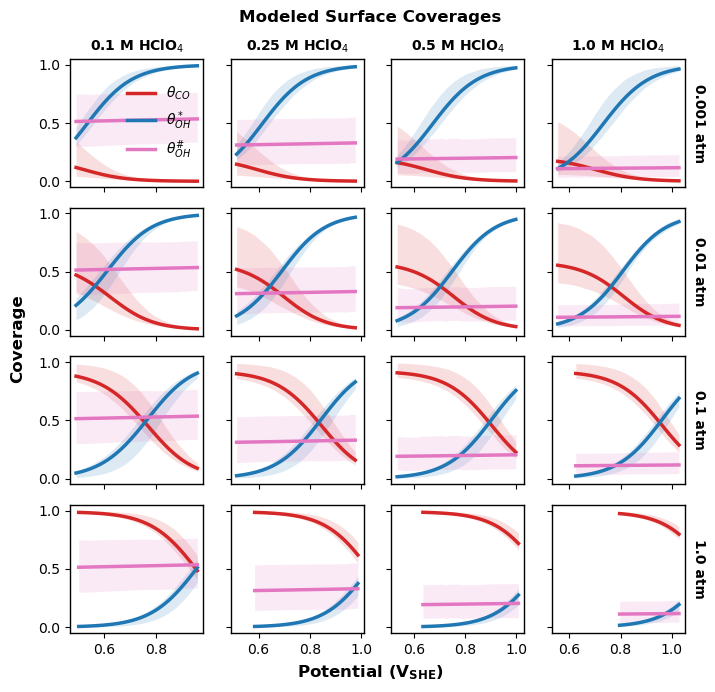

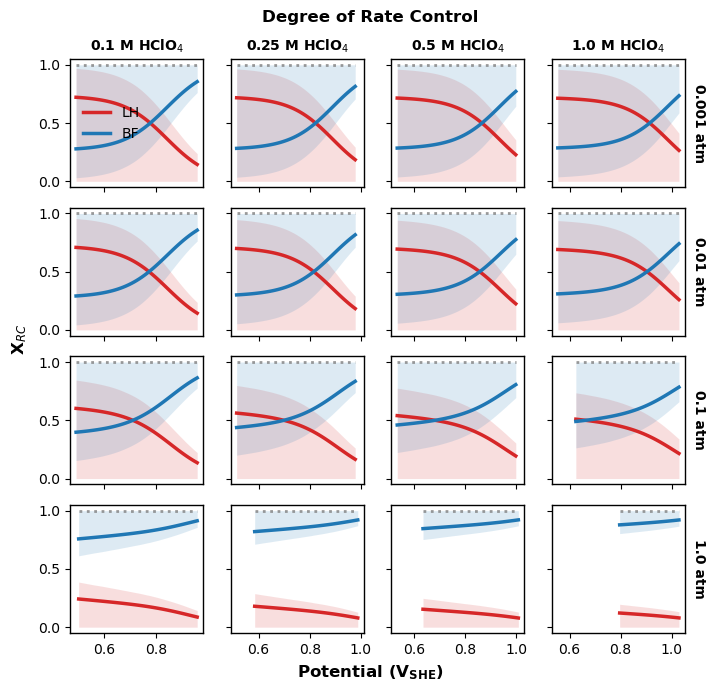

In [14]:
ppc_LH_BF_PCT = plot_posteriors(trace_LH_BF_PCT, LH_BF_PCT)
plot_model_fits(trace_LH_BF_PCT, ppc_LH_BF_PCT); plot_coverages(trace_LH_BF_PCT)
plot_drc(LH_BF_PCT, trace_LH_BF_PCT, perturb_vars=['Gact2_LH_0', 'Gact2_BF_0'], perturb_labels=['LH', 'BF'], 
         var_types={'Gact2_LH_0': 'Gact', 'Gact2_BF_0': 'Gact'})

# Comparison

           rank    elpd_loo       p_loo   elpd_diff        weight         se        dse  warning scale
LH_BF_PCT     0  944.465047   77.519749    0.000000  3.921337e-01  47.327144   0.000000    False   log
LH_PCT        1  861.505530   10.705861   82.959517  2.766290e-01  44.709371  25.342259    False   log
ER_2          2  772.220687   11.708417  172.244360  3.312374e-01  64.646412  35.791480    False   log
BF_PCT        3  238.595227  455.447066  705.869820  2.405674e-08  71.256234  40.948706     True   log
LH_2          4   66.862563    9.510887  877.602484  1.843382e-08  34.592111  32.155317    False   log
BF_2          5   48.759737  721.512104  895.705310  0.000000e+00  43.208837  26.356778     True   log


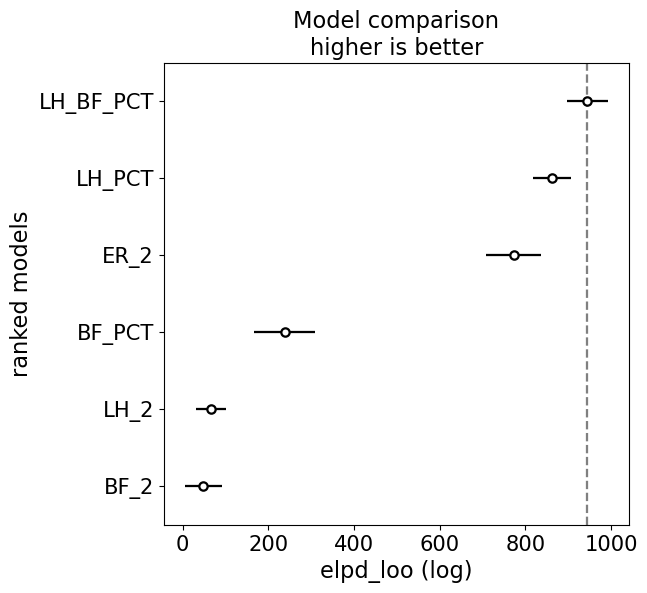

In [15]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2, 
    "BF_2": loo_BF_2,
    "LH_PCT": loo_LH_PCT,
    "BF_PCT": loo_BF_PCT, 
    "LH_BF_PCT": loo_LH_BF_PCT
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()